# CutTrack

Ett verktyg för att logga vikt, kalorier, protein, steg och träning under en deff, och få regelbaserade råd om vikten och kosten rör sig åt rätt håll.

Notebooken innehåller:

**Klasser**

- `DailyLog`, en enskild dags logg, med validering av vikt och kalorier
- `User`, basklassen med användarens grunddata och metoderna som räknar på loggarna
- `CutProfile`, barnklassen som ärver från `User` och lägger till mål, kaloriberäkningar och råd

**Funktioner**

- `log_today`, frågar användaren om dagens värden och lägger till en logg
- `make_filename`, bygger ett säkert filnamn från användarnamnet
- `save_profile` och `load_profile`, sparar och läser profilen som JSON
- `export_logs_csv` och `import_logs_csv`, loggarna som CSV
- `plot_weight`, viktdiagram med matplotlib
- `show_welcome`, `create_profile` och `run_menu`, menyn som binder ihop allt
- `plot_weight`, viktdiagram med matplotlib
- `show_welcome`, `create_profile` och `run_menu`, menyn som binder ihop allt
- `run_menu`, menyn som binder ihop allt

Kör cellerna uppifrån och ner. Klasserna måste definieras innan funktionerna som använder dem.

In [104]:
from datetime import datetime
import json
import csv
import os
import matplotlib.pyplot as plt

## DailyLog

Representerar en dags logg. Kontrollerar i `__init__` att vikt och kalorier är rimliga tal. Är de inte det kastas ett `ValueError` med ett förklarande meddelande, som fångas längre ner i `log_today`.

Gränserna (0 till 300 kg, 0 till 10 000 kcal) är satta för att fånga uppenbara skrivfel, som ett extra 0 eller ett minustecken, inte för att vara medicinskt exakta.

`trained` är en bool, `True` om personen tränade den dagen. Under en deff är det träningsfrekvensen som håller muskelmassan uppe, inte hur många minuter passet varade. Ett långt pass med mycket vila ger inte mer stimulans än ett kort och fokuserat. Frekvens går dessutom att bedöma mot en tydlig regel, antal dagar per vecka, medan minuter kräver ett godtyckligt tröskelvärde.

`waist` har standardvärdet `None`, eftersom midjemått är en valfri mätning. Att `None` inte är samma sak som 0 spelar roll längre fram, när snitt ska räknas och skilja på utebliven mätning och ett mätvärde på 0 cm.

In [105]:
class DailyLog:
    """En daglig logg med vikt, kalorier och annan data för ett datum."""

    def __init__(self, date, weight, calories, protein, steps, trained, waist=None):
        if weight <= 0 or weight > 300:
            raise ValueError("Vikten måste vara ett rimligt tal i kilogram, till exempel 82.5.")
        if calories < 0 or calories > 10000:
            raise ValueError("Kalorierna måste vara ett rimligt tal, till exempel 2200.")

        self.date = date
        self.weight = weight
        self.calories = calories
        self.protein = protein
        self.steps = steps
        self.trained = trained
        self.waist = waist

## User

Basklassen för en användare. Innehåller personens grunddata och listan med loggar, plus metoderna som räknar på loggarna.

`logs` börjar som en tom lista. Varje logg som läggs till är ett `DailyLog`-objekt.

Metoderna:

- `add_log`, lägger till en logg, eller byter ut den befintliga om det redan finns en logg för samma datum
- `get_logs(days)`, plockar ut loggarna från de senaste `days` kalenderdagarna
- `average_weight(days)`, medelvikt över perioden
- `weight_change(days)`, hur mycket vikten ändrats över perioden
- `training_days(days)`, antal dagar med träning under perioden

In [106]:
class User:
    """Basklass för en användare av CutTrack."""

    def __init__(self, name, height_cm, age, sex, activity_level, start_weight, created_date):
        self.name = name
        self.height_cm = height_cm
        self.age = age
        self.sex = sex
        self.activity_level = activity_level
        self.start_weight = start_weight
        self.created_date = created_date
        self.logs = []

    def add_log(self, new_log):
        for i in range(len(self.logs)):
            if self.logs[i].date == new_log.date:
                self.logs[i] = new_log
                print(f"Loggen för {new_log.date} uppdaterades.")
                return
        self.logs.append(new_log)
        print(f"Loggen för {new_log.date} lades till.")

    def get_logs(self, days):
        """Returnerar loggarna från de senaste days kalenderdagarna."""
        if len(self.logs) == 0:
            return []

        latest_date = None
        for log in self.logs:
            log_date = datetime.strptime(log.date, "%Y-%m-%d")
            if latest_date is None or log_date > latest_date:
                latest_date = log_date

        selected_logs = []
        for log in self.logs:
            log_date = datetime.strptime(log.date, "%Y-%m-%d")
            days_ago = (latest_date - log_date).days
            if days_ago < days:
                selected_logs.append(log)

        return selected_logs

    def average_weight(self, days):
        """Medelvikt över perioden. Returnerar None om det inte finns några loggar."""
        selected_logs = self.get_logs(days)

        if len(selected_logs) == 0:
            return None

        total_weight = 0
        for log in selected_logs:
            total_weight = total_weight + log.weight

        return total_weight / len(selected_logs)

    def average_protein(self, days):
        """Medelprotein i gram över perioden. Returnerar None om det inte finns några loggar."""
        selected_logs = self.get_logs(days)

        if len(selected_logs) == 0:
            return None

        total_protein = 0
        for log in selected_logs:
            total_protein = total_protein + log.protein

        return total_protein / len(selected_logs)

    def average_steps(self, days):
        """Medelantal steg över perioden. Returnerar None om det inte finns några loggar."""
        selected_logs = self.get_logs(days)

        if len(selected_logs) == 0:
            return None

        total_steps = 0
        for log in selected_logs:
            total_steps = total_steps + log.steps

        return total_steps / len(selected_logs)

    def weight_change(self, days):
        """Viktförändring i kg över perioden. Negativt tal betyder att vikten gått ner.
        Returnerar None om det finns färre än två loggar."""
        selected_logs = self.get_logs(days)

        if len(selected_logs) < 2:
            return None

        first_log = selected_logs[0]
        last_log = selected_logs[0]
        for log in selected_logs:
            if log.date < first_log.date:
                first_log = log
            if log.date > last_log.date:
                last_log = log

        return last_log.weight - first_log.weight

    def training_days(self, days):
        """Antal dagar med träning under perioden."""
        selected_logs = self.get_logs(days)

        total_days = 0
        for log in selected_logs:
            if log.trained:
                total_days = total_days + 1

        return total_days

### Hur get_logs räknar kalenderdagar

Enligt teknisk_plan.md ska fönstret räknas på kalenderdagar, inte på antal loggar. Sju loggar utspridda över en månad är inte ett veckosnitt.

Metoden gör tre saker:

1. Loopar igenom alla loggar och hittar det senaste datumet. `datetime.strptime` gör om datumsträngen till ett datumobjekt som går att jämföra med `>`.
2. Loopar igenom alla loggar igen och räknar ut hur många dagar bakåt varje logg ligger, genom att dra det ena datumet från det andra och läsa `.days`.
3. Tar med loggen om den ligger inom fönstret.

`average_weight`, `weight_change` och `training_days` anropar alla `get_logs` först, så urvalsregeln finns på ett enda ställe. Ändras regeln behöver bara `get_logs` ändras.

`weight_change` sorterar inte listan. Den loopar igenom och hittar den tidigaste och den senaste loggen genom att jämföra datumsträngarna direkt. Det fungerar eftersom formatet ÅÅÅÅ-MM-DD sorteras rätt som text, vilket är skälet till att just det formatet valdes i teknisk_plan.md.

`average_weight` och `weight_change` returnerar `None` när underlaget är för tunt, inga loggar alls respektive färre än två. Det skiljer sig från att returnera 0, som skulle betyda att vikten inte ändrades. `training_days` returnerar däremot 0 när det inte finns några loggar, eftersom noll träningsdagar är ett korrekt svar och inte ett saknat värde.

## CutProfile, barnklass med arv

`CutProfile` ärver från `User`. Allt som `User` kan, kan `CutProfile` också: `add_log`, `get_logs`, `average_weight`, `weight_change` och `training_days` finns utan att skrivas om.

Det som läggs till är målen och kaloriberäkningarna, alltså det som är specifikt för någon som deffar. En framtida `BulkProfile` eller `MaintenanceProfile` skulle kunna ärva från samma `User` utan att röra den koden.

`super().__init__(...)` anropar förälderklassens `__init__`, som sätter namn, längd, ålder, kön, aktivitetsnivå, startvikt, datum och den tomma logglistan. Sedan sätter `CutProfile` sina egna attribut. Utan `super()` skulle inget av `User`-attributen finnas, och `self.logs` skulle inte existera.

`protein_goal_per_kg` och `step_goal` har standardvärden, så de kan utelämnas när en profil skapas. `calorie_goal` sätts till `None` från start eftersom den räknas ut först senare, av `suggest_calorie_goal`.

In [107]:
class CutProfile(User):
    """En användare som deffar. Ärver allt från User och lägger till mål och kaloriberäkningar."""

    def __init__(self, name, height_cm, age, sex, activity_level, start_weight, created_date,
                 goal_weight, target_rate_percent, protein_goal_per_kg=1.9, step_goal=8000,
                 training_goal_days=3):
        super().__init__(name, height_cm, age, sex, activity_level, start_weight, created_date)

        if goal_weight <= 0 or goal_weight >= start_weight:
            raise ValueError("Målvikten måste vara lägre än startvikten.")
        if target_rate_percent <= 0 or target_rate_percent > 1.0:
            raise ValueError("Takten måste ligga mellan 0 och 1,0 procent av kroppsvikten per vecka.")

        self.goal_weight = goal_weight
        self.target_rate_percent = target_rate_percent
        self.protein_goal_per_kg = protein_goal_per_kg
        self.step_goal = step_goal
        self.training_goal_days = training_goal_days
        self.calorie_goal = None

    def current_weight(self):
        """Senaste loggade vikten. Startvikten om inga loggar finns."""
        if len(self.logs) == 0:
            return self.start_weight

        latest_log = self.logs[0]
        for log in self.logs:
            if log.date > latest_log.date:
                latest_log = log

        return latest_log.weight

    def calculate_bmr(self):
        """Basalomsättning i kalorier per dygn, enligt Mifflin-St Jeor."""
        weight = self.current_weight()
        bmr = 10 * weight + 6.25 * self.height_cm - 5 * self.age

        if self.sex == "man":
            bmr = bmr + 5
        else:
            bmr = bmr - 161

        return bmr

    def calculate_tdee(self):
        """Totalt dagligt energibehov, basalomsättningen gånger aktivitetsfaktorn."""
        return self.calculate_bmr() * self.activity_level

    def protein_goal(self):
        """Proteinmål i gram per dag, räknat på målvikten."""
        return self.goal_weight * self.protein_goal_per_kg

    def suggest_calorie_goal(self):
        """Räknar ut ett dagligt kaloriförslag utifrån önskad takt.
        Går aldrig under golvet, som är det högsta av basalomsättningen
        och en fast gräns (1500 kcal för män, 1200 för kvinnor)."""
        tdee = self.calculate_tdee()
        bmr = self.calculate_bmr()
        weight = self.current_weight()

        weekly_loss_kg = weight * self.target_rate_percent / 100
        daily_deficit = weekly_loss_kg * 7700 / 7
        suggested_calories = tdee - daily_deficit

        if self.sex == "man":
            fixed_floor = 1500
        else:
            fixed_floor = 1200

        if bmr > fixed_floor:
            floor = bmr
        else:
            floor = fixed_floor

        if suggested_calories < floor:
            print("Kaloriförslaget hamnade under ditt golv och har justerats upp.")
            print(f"Golvet är {round(floor)} kcal, det högsta av din basalomsättning "
                  f"({round(bmr)}) och den fasta gränsen ({fixed_floor}).")
            suggested_calories = floor

            actual_deficit = tdee - floor
            if actual_deficit <= 0:
                print("Med ditt golv går det inte att skapa något underskott genom maten.")
                print("Vägen framåt är att röra dig mer, inte att äta mindre.")
            else:
                actual_weekly_loss = actual_deficit * 7 / 7700
                actual_rate = actual_weekly_loss / weight * 100
                print(f"Takten blir därför {round(actual_rate, 2)} procent per vecka "
                      f"i stället för {self.target_rate_percent}.")
                print("Vill du gå ner snabbare är vägen dit att röra dig mer, inte att äta mindre.")

        self.calorie_goal = round(suggested_calories)
        return self.calorie_goal

    def days_since_start(self):
        """Antal dagar sedan profilen skapades, räknat till senaste loggade dagen."""
        if len(self.logs) == 0:
            return 0

        latest_log = self.logs[0]
        for log in self.logs:
            if log.date > latest_log.date:
                latest_log = log

        start_date = datetime.strptime(self.created_date, "%Y-%m-%d")
        latest_date = datetime.strptime(latest_log.date, "%Y-%m-%d")
        return (latest_date - start_date).days + 1

    def waiting_message(self):
        """Text för dag 1 till 13, innan full analys är möjlig. Returnerar None från dag 14."""
        days = self.days_since_start()

        if days < 7:
            remaining = 7 - days
            return ("Vikten svänger flera hundra gram från dag till dag på grund av vätska och "
                    "maginnehåll, mer än en hel veckas verkliga fettförlust. Ett råd byggt på "
                    f"{days} dagars data vore bara brus. {remaining} dagar kvar tills ett "
                    "sjudagarssnitt visas.")

        if days < 14:
            remaining = 14 - days
            return ("Sjudagarssnittet är nu tillräckligt med data för att visas, men takten går "
                    f"inte att bedöma säkert än. {remaining} dagar kvar tills full analys är möjlig.")

        return None

    def check_goals(self):
        """Statusöversikt över vikt, protein, träningsfrekvens och steg, plus en sak att
        fokusera på. Prioritetsordning: vikt, protein, träningsfrekvens, steg."""
        waiting_text = self.waiting_message()
        if waiting_text is not None:
            print(waiting_text)
            return

        focus_area = None

        # Vikt: undre gränsen är personens eget mål, övre gränsen är ett fast säkerhetstak
        weekly_change = self.weight_change(7)
        avg_weight = self.average_weight(7)
        if weekly_change is not None and avg_weight is not None and avg_weight > 0:
            rate_percent = -weekly_change / avg_weight * 100
            if weekly_change > 0:
                print(f"Vikten: ökar med {round(weekly_change, 1)} kg den senaste veckan. "
                      "Underskottet räcker inte.")
                focus_area = "vikt"
            elif rate_percent > 1.0:
                print(f"Vikten: minskar med {round(rate_percent, 2)} procent per vecka, över "
                      "säkerhetsgränsen 1,0 procent. Risk för muskelförlust.")
                if focus_area is None:
                    focus_area = "vikt"
            elif rate_percent < self.target_rate_percent:
                print(f"Vikten: minskar med {round(rate_percent, 2)} procent per vecka, "
                      f"långsammare än ditt mål på {self.target_rate_percent} procent.")
                if focus_area is None:
                    focus_area = "vikt"
            else:
                print(f"Vikten: minskar med {round(rate_percent, 2)} procent per vecka, vid "
                      f"eller över ditt mål på {self.target_rate_percent} procent och inom "
                      "säkerhetsgränsen.")
        else:
            print("Vikten: för lite data för att bedöma takten.")

        # Protein
        avg_protein = self.average_protein(7)
        protein_target = self.protein_goal()
        if avg_protein is not None:
            if avg_protein < protein_target:
                print(f"Protein: snitt {round(avg_protein)} g mot mål {round(protein_target)} g. "
                      "Under målet.")
                if focus_area is None:
                    focus_area = "protein"
            else:
                print(f"Protein: snitt {round(avg_protein)} g mot mål {round(protein_target)} g. "
                      "Målet nås.")
        else:
            print("Protein: för lite data.")

        # Träningsfrekvens
        training_count = self.training_days(7)
        if training_count < self.training_goal_days:
            print(f"Träning: {training_count} av {self.training_goal_days} planerade dagar den "
                  "senaste veckan. Under målet.")
            if focus_area is None:
                focus_area = "träning"
        else:
            print(f"Träning: {training_count} av {self.training_goal_days} planerade dagar den "
                  "senaste veckan. Målet nås.")

        # Steg
        avg_steps = self.average_steps(7)
        if avg_steps is not None:
            if avg_steps < self.step_goal:
                print(f"Steg: snitt {round(avg_steps)} mot mål {self.step_goal}. Under målet.")
                if focus_area is None:
                    focus_area = "steg"
            else:
                print(f"Steg: snitt {round(avg_steps)} mot mål {self.step_goal}. Målet nås.")
        else:
            print("Steg: för lite data.")

        print()
        if focus_area is None:
            print("Allt ligger inom mål just nu. Fortsätt som du gör.")
        else:
            print(f"Fokusera på: {focus_area}.")

### Om beräkningarna

**Mifflin-St Jeor** räknar ut basalomsättningen, alltså hur många kalorier kroppen gör av med i vila. Formeln är densamma för båda könen så när som på sista termen, plus 5 för män och minus 161 för kvinnor. Därför står den gemensamma delen först och if-satsen justerar bara slutet.

**`current_weight`** finns för att BMR ska räknas på vad personen väger nu, inte på startvikten. Under en deff sjunker vikten, och därmed sjunker också förbrukningen. Räknas BMR på startvikten överskattas behovet mer och mer ju längre deffen pågår.

Den hittar senaste loggen genom att jämföra datumsträngar, precis som `weight_change`, och faller tillbaka på `start_weight` när det inte finns några loggar än.

**`calculate_tdee`** multiplicerar med aktivitetsfaktorn: 1,2 stillasittande, 1,375 lätt aktiv, 1,55 måttligt aktiv, 1,725 mycket aktiv, 1,9 extremt aktiv.

**`protein_goal`** räknas på målvikten och inte på nuvarande vikt. Målet ligger därmed fast under hela deffen i stället för att sjunka i takt med att vikten går ner, vilket vore fel: proteinbehovet finns för att skydda den muskelmassa som ska vara kvar när deffen är slut.

**Valideringen** i `__init__` fångar två saker som gör resten av beräkningarna meningslösa: en målvikt som är högre än startvikten, och en takt över 1,0 procent per vecka, där risken för muskelförlust blir för stor. Samma mönster som i `DailyLog`, felet kastas där objektet skapas.

### Test av CutProfile

Testcellen visar tre saker: att formeln stämmer mot handräknat facit, att de ärvda metoderna från `User` fungerar utan att vara omskrivna, och att `isinstance` bekräftar arvet.

In [108]:
profile = CutProfile("Niklas", 183, 39, "man", 1.55, 90.0, "2026-09-01",
                     goal_weight=82.0, target_rate_percent=0.7)

print("Basalomsättning:", round(profile.calculate_bmr(), 1))
print("Energibehov:", round(profile.calculate_tdee(), 1))
print("Proteinmål:", round(profile.protein_goal(), 1), "gram")
print("Aktuell vikt utan loggar:", profile.current_weight())

profile.add_log(DailyLog("2026-09-15", 89.0, 2200, 150, 8000, True))
profile.add_log(DailyLog("2026-09-16", 88.6, 2150, 160, 9000, False))

print("Aktuell vikt med loggar:", profile.current_weight())
print("Basalomsättning nu:", round(profile.calculate_bmr(), 1))
print("Medelvikt 7 dagar:", profile.average_weight(7))
print("Träningsdagar 7 dagar:", profile.training_days(7))
print("Är CutProfile också en User?", isinstance(profile, User))

Basalomsättning: 1853.8
Energibehov: 2873.3
Proteinmål: 155.8 gram
Aktuell vikt utan loggar: 90.0
Loggen för 2026-09-15 lades till.
Loggen för 2026-09-16 lades till.
Aktuell vikt med loggar: 88.6
Basalomsättning nu: 1839.8
Medelvikt 7 dagar: 88.8
Träningsdagar 7 dagar: 1
Är CutProfile också en User? True


In [109]:
# Valideringen ska stoppa orimliga profiler
try:
    CutProfile("Test", 180, 30, "man", 1.2, 80.0, "2026-09-01",
               goal_weight=85.0, target_rate_percent=0.5)
except ValueError as error:
    print("Fångat fel:", error)

try:
    CutProfile("Test", 180, 30, "man", 1.2, 80.0, "2026-09-01",
               goal_weight=75.0, target_rate_percent=1.5)
except ValueError as error:
    print("Fångat fel:", error)

Fångat fel: Målvikten måste vara lägre än startvikten.
Fångat fel: Takten måste ligga mellan 0 och 1,0 procent av kroppsvikten per vecka.


### suggest_calorie_goal

Metoden räknar ut hur många kalorier personen bör äta per dag, och är den enda i projektet som kan vägra göra som användaren bett om.

**Steg för steg:**

1. Räkna ut hur många kilo i veckan den önskade takten motsvarar: vikten gånger procenttalet delat med 100.
2. Gör om det till ett dagligt underskott med tumregeln 7700 kcal per kilo kroppsfett, delat på veckans sju dagar.
3. Dra underskottet från energibehovet.
4. Kontrollera mot golvet, och justera upp om förslaget hamnade under.

**Golvet** är det högsta av två värden: den fasta gränsen (1500 kcal för män, 1200 för kvinnor) och personens egen basalomsättning. Är basalomsättningen 1780 blir golvet 1780, inte 1500. Fördelen med det rörliga golvet är att det skalar med personen, vilket ett fast tal inte gör.

**Programmet justerar inte tyst.** Slår golvet i skrivs det ut vad som hände, vilket golv som gällde, och vilken takt som faktiskt blir möjlig. Tyst justering skulle få användaren att tro att den snabba takten fortfarande gäller.

**En konsekvens värd att känna till:** en stillasittande person har aktivitetsfaktor 1,2, alltså är energibehovet bara 20 procent över basalomsättningen. Största möjliga underskott blir därmed litet, och takten hamnar ofta runt 0,4 procent per vecka oavsett vad personen önskat. Det är inte en bugg. Slutsatsen programmet drar är att vägen till snabbare viktnedgång går via mer aktivitet, inte via mindre mat, och det säger det uttryckligen.

**Om 7700-regeln:** siffran kommer från en artikel från 1958 och antar ett konstant energiunderskott, vilket inte stämmer. När vikten sjunker sjunker även förbrukningen, så samma underskott ger mindre effekt över tid. Regeln överskattar alltså den faktiska viktnedgången. Den används här som startpunkt just för att den är enkel och går att förklara, och tanken är att siffran justeras mot verkligt utfall efter ett par veckor. Det är ett medvetet val av en enkel modell med kända begränsningar.

### Test av suggest_calorie_goal

Tre fall: ett där golvet inte slår i, ett där det gör det, och ett där energibehovet är så lågt att inget underskott alls går att skapa genom maten.

In [110]:
print("Fall 1, golvet slår inte i")
a = CutProfile("Niklas", 183, 39, "man", 1.55, 90.0, "2026-09-01",
               goal_weight=82.0, target_rate_percent=0.7)
print("Energibehov:", round(a.calculate_tdee()), "Basalomsättning:", round(a.calculate_bmr()))
print("Kaloriförslag:", a.suggest_calorie_goal())
print()

print("Fall 2, golvet slår i")
b = CutProfile("Testperson", 155, 30, "kvinna", 1.2, 55.0, "2026-09-01",
               goal_weight=50.0, target_rate_percent=1.0)
print("Energibehov:", round(b.calculate_tdee()), "Basalomsättning:", round(b.calculate_bmr()))
print("Kaloriförslag:", b.suggest_calorie_goal())
print()

print("Fall 3, inget underskott möjligt genom maten")
c = CutProfile("Testperson", 150, 65, "kvinna", 1.2, 48.0, "2026-09-01",
               goal_weight=45.0, target_rate_percent=1.0)
print("Energibehov:", round(c.calculate_tdee()), "Basalomsättning:", round(c.calculate_bmr()))
print("Kaloriförslag:", c.suggest_calorie_goal())

Fall 1, golvet slår inte i
Energibehov: 2873 Basalomsättning: 1854
Kaloriförslag: 2180

Fall 2, golvet slår i
Energibehov: 1449 Basalomsättning: 1208
Kaloriförslaget hamnade under ditt golv och har justerats upp.
Golvet är 1208 kcal, det högsta av din basalomsättning (1208) och den fasta gränsen (1200).
Takten blir därför 0.4 procent per vecka i stället för 1.0.
Vill du gå ner snabbare är vägen dit att röra dig mer, inte att äta mindre.
Kaloriförslag: 1208

Fall 3, inget underskott möjligt genom maten
Energibehov: 1118 Basalomsättning: 932
Kaloriförslaget hamnade under ditt golv och har justerats upp.
Golvet är 1200 kcal, det högsta av din basalomsättning (932) och den fasta gränsen (1200).
Med ditt golv går det inte att skapa något underskott genom maten.
Vägen framåt är att röra dig mer, inte att äta mindre.
Kaloriförslag: 1200


### days_since_start och waiting_message

Dagliga viktsvängningar från vätska och maginnehåll ligger ofta på flera hundra gram, mer än en hel veckas verkliga fettförlust. Ett råd byggt på tre dagars data är brus, inte information.

`days_since_start` räknar från `created_date` till den senast loggade dagen, inte till dagens riktiga datum. Det håller samma princip som `get_logs`: har du inte loggat på några dagar ska analysen ändå utgå från din senaste aktiva period.

`waiting_message` returnerar text dag 1 till 13, och `None` från dag 14. `check_goals` kollar detta först, och avbryter tidigt om det finns text att visa i stället för en analys.

### check_goals

Ger en statusrad för vikt, protein, träningsfrekvens och steg, i den ordningen, och lyfter sedan fram en enda sak att fokusera på.

**Vikten** bedöms mot två olika gränser med olika syften. Den undre gränsen är personens eget `target_rate_percent`, vad de själva bett om. Den övre gränsen är ett fast säkerhetstak på 1,0 procent per vecka, oavsett vad personen satt som mål. Skälet till skillnaden: hur snabbt någon vill gå ner är en fråga om preferens, men risken för muskelförlust vid för snabb nedgång är en fråga om säkerhet, och säkerhet ska inte gå att ställa in bort. Sätter någon sitt mål till 0,3 procent och landar på 0,3, är det precis vad de bad om, inte för långsamt. Landar de på 1,3, flaggas det, även om de själva satt målet till 1,0.

**Protein, träning och steg** kräver bara ett snitt, ingen trend, och analyseras därför oavsett hur många dagar som gått, till skillnad från vikten.

**`focus_area`** sätts bara av det första området som inte når sitt mål, tack vare `if focus_area is None:` i varje gren. Vikt kollas först i koden, så ett viktproblem vinner alltid över ett proteinproblem, oavsett i vilken ordning de faktiskt upptäcks. Är allt inom mål förblir `focus_area` `None`, och en positiv sammanfattning skrivs i stället, byggd på att inget slog till, inte på en generell fras.

### Test av check_goals

Fyra scenarier: tidig väntetext, allt inom mål, vikten går fel håll, och ett lågt personligt mål som ändå nås snabbare men säkert och därför inte flaggas.

In [111]:
from datetime import timedelta

def add_days_of_logs(profile, start, num_days, weight_start, daily_change,
                      calories, protein, steps, trained_pattern):
    """Hjälpfunktion bara för testning, lägger till num_days loggar i rad."""
    start_date = datetime.strptime(start, "%Y-%m-%d")
    for i in range(num_days):
        date_text = (start_date + timedelta(days=i)).strftime("%Y-%m-%d")
        weight = round(weight_start + daily_change * i, 1)
        trained = trained_pattern[i % len(trained_pattern)]
        profile.add_log(DailyLog(date_text, weight, calories, protein, steps, trained))

In [112]:
print("Dag 3, väntetext:")
early = CutProfile("Test", 183, 39, "man", 1.55, 90.0, "2026-09-01", 82.0, 0.7)
add_days_of_logs(early, "2026-09-01", 3, 90.0, -0.05, 2200, 150, 8000, [True, False, True])
early.check_goals()
print()

print("Dag 20, allt inom mål:")
good = CutProfile("Test", 183, 39, "man", 1.55, 90.0, "2026-09-01", 82.0, 0.7)
add_days_of_logs(good, "2026-09-01", 20, 90.0, -0.10, 2000, 175, 9000, [True, True, False, True])
good.check_goals()
print()

print("Dag 20, vikten ökar:")
wrong_way = CutProfile("Test", 183, 39, "man", 1.55, 90.0, "2026-09-01", 82.0, 0.7)
add_days_of_logs(wrong_way, "2026-09-01", 20, 90.0, 0.05, 2600, 175, 9000, [True, True, False, True])
wrong_way.check_goals()
print()

print("Dag 20, lågt personligt mål, snabbare men säkert, ska inte flaggas:")
low_goal = CutProfile("Test", 183, 39, "man", 1.55, 90.0, "2026-09-01", 88.0, 0.3)
add_days_of_logs(low_goal, "2026-09-01", 20, 90.0, -0.10, 2000, 175, 9000, [True, True, False, True])
low_goal.check_goals()

Dag 3, väntetext:
Loggen för 2026-09-01 lades till.
Loggen för 2026-09-02 lades till.
Loggen för 2026-09-03 lades till.
Vikten svänger flera hundra gram från dag till dag på grund av vätska och maginnehåll, mer än en hel veckas verkliga fettförlust. Ett råd byggt på 3 dagars data vore bara brus. 4 dagar kvar tills ett sjudagarssnitt visas.

Dag 20, allt inom mål:
Loggen för 2026-09-01 lades till.
Loggen för 2026-09-02 lades till.
Loggen för 2026-09-03 lades till.
Loggen för 2026-09-04 lades till.
Loggen för 2026-09-05 lades till.
Loggen för 2026-09-06 lades till.
Loggen för 2026-09-07 lades till.
Loggen för 2026-09-08 lades till.
Loggen för 2026-09-09 lades till.
Loggen för 2026-09-10 lades till.
Loggen för 2026-09-11 lades till.
Loggen för 2026-09-12 lades till.
Loggen för 2026-09-13 lades till.
Loggen för 2026-09-14 lades till.
Loggen för 2026-09-15 lades till.
Loggen för 2026-09-16 lades till.
Loggen för 2026-09-17 lades till.
Loggen för 2026-09-18 lades till.
Loggen för 2026-09-19 

## log_today

Frågar efter dagens värden med `input()`, skapar ett `DailyLog`-objekt och lägger till det på användaren via `add_log`.

Datumformatet kontrolleras med `datetime.strptime`, som kastar `ValueError` om texten inte följer formatet ÅÅÅÅ-MM-DD. Det felet, `ValueError` från `DailyLog` om vikt eller kalorier är orimliga, och `ValueError` från `float()` eller `int()` om någon skriver in text där ett tal förväntas, fångas alla av samma `try/except`, eftersom de är samma feltyp.

Träningsfrågan besvaras med j eller n. Svaret görs om till små bokstäver med `.lower()` så att både J och j fungerar, och jämförs sedan mot strängen `"j"`. Resultatet av jämförelsen är redan `True` eller `False`, så det kan sparas direkt i `trained` utan en if-sats.

Går något fel sparas ingen logg, och felmeddelandet skrivs ut. Användaren får då köra `log_today(user)` igen.

In [113]:
def log_today(user):
    """Frågar användaren om dagens värden och lägger till en DailyLog på user."""
    date_text = input("Datum (ÅÅÅÅ-MM-DD): ")

    try:
        datetime.strptime(date_text, "%Y-%m-%d")
        weight = float(input("Vikt i kg: "))
        calories = float(input("Kalorier: "))
        protein = float(input("Protein i gram: "))
        steps = int(input("Steg: "))

        trained_text = input("Tränade du idag? (j/n): ")
        trained = trained_text.lower() == "j"

        waist_text = input("Midjemått i cm (lämna tomt om du inte mätt): ")
        if waist_text == "":
            waist = None
        else:
            waist = float(waist_text)

        new_log = DailyLog(date_text, weight, calories, protein, steps, trained, waist)
        user.add_log(new_log)

    except ValueError as error:
        print(f"Loggen sparades inte. Något var fel i inmatningen: {error}")

## Test

Cellen nedan skapar en användare och lägger till fem loggar direkt i koden, så att metoderna går att testa utan att mata in allt för hand.

Den sista loggen ligger långt bak i tiden och ska därför inte räknas med i sjudagarsfönstret, men väl i sextiodagarsfönstret.

In [114]:
test_user = User("Niklas", 183, 39, "man", 1.55, 90.0, "2026-09-01")

test_user.add_log(DailyLog("2026-09-15", 90.0, 2200, 150, 8000, True))
test_user.add_log(DailyLog("2026-09-16", 89.6, 2150, 160, 9000, False))
test_user.add_log(DailyLog("2026-09-17", 89.8, 2300, 145, 7000, True))
test_user.add_log(DailyLog("2026-09-18", 89.2, 2100, 155, 8500, True))
test_user.add_log(DailyLog("2026-08-01", 95.0, 2500, 120, 5000, False))

print("Loggar totalt:", len(test_user.logs))
print("Loggar i sjudagarsfönstret:", len(test_user.get_logs(7)))
print("Medelvikt 7 dagar:", test_user.average_weight(7))
print("Medelvikt 60 dagar:", test_user.average_weight(60))
print("Viktförändring 7 dagar:", test_user.weight_change(7))
print("Träningsdagar 7 dagar:", test_user.training_days(7))
print("Träningsdagar 60 dagar:", test_user.training_days(60))

Loggen för 2026-09-15 lades till.
Loggen för 2026-09-16 lades till.
Loggen för 2026-09-17 lades till.
Loggen för 2026-09-18 lades till.
Loggen för 2026-08-01 lades till.
Loggar totalt: 5
Loggar i sjudagarsfönstret: 4
Medelvikt 7 dagar: 89.64999999999999
Medelvikt 60 dagar: 90.72
Viktförändring 7 dagar: -0.7999999999999972
Träningsdagar 7 dagar: 3
Träningsdagar 60 dagar: 3


### Test med egen inmatning

Kör cellen nedan och fyll i värden själv. Testa både ett giltigt försök och minst ett medvetet felaktigt (fel datumformat, orimlig vikt, text där ett tal förväntas), så att du sett `except`-grenen köras på riktigt.

Kör den sedan en gång till med samma datum som förra gången, för att se att `add_log` uppdaterar posten i stället för att lägga till en till.

In [115]:
log_today(test_user)

Loggen för 2026-12-31 lades till.


In [116]:
for log in test_user.logs:
    print(vars(log))

{'date': '2026-09-15', 'weight': 90.0, 'calories': 2200, 'protein': 150, 'steps': 8000, 'trained': True, 'waist': None}
{'date': '2026-09-16', 'weight': 89.6, 'calories': 2150, 'protein': 160, 'steps': 9000, 'trained': False, 'waist': None}
{'date': '2026-09-17', 'weight': 89.8, 'calories': 2300, 'protein': 145, 'steps': 7000, 'trained': True, 'waist': None}
{'date': '2026-09-18', 'weight': 89.2, 'calories': 2100, 'protein': 155, 'steps': 8500, 'trained': True, 'waist': None}
{'date': '2026-08-01', 'weight': 95.0, 'calories': 2500, 'protein': 120, 'steps': 5000, 'trained': False, 'waist': None}
{'date': '2026-12-31', 'weight': 89.0, 'calories': 2200.0, 'protein': 8000.0, 'steps': 8000, 'trained': True, 'waist': None}


## Filhantering: spara och läsa profiler

Profilen och alla loggar sparas som JSON, en fil per användare. Filnamnet byggs från användarnamnet.

### make_filename

Filnamnet får aldrig byggas direkt av det användaren skriver in. Skriver någon `../../etc/passwd` som namn skulle programmet annars försöka skriva utanför sin egen mapp.

Lösningen är en loop som går igenom namnet tecken för tecken och bara behåller de som finns i `ALLOWED_CHARACTERS`, alltså a till z och siffror. Allt annat, mellanslag, bindestreck, snedstreck och punkter, försvinner. "Niklas E" blir `niklase.json`.

Å, ä och ö tas också bort. De är bokstäver, men svenska tecken i filnamn kan ge problem när filer flyttas mellan olika operativsystem, så de utelämnas medvetet. "Anna-Lena Ö" blir `annalena.json`.

Blir resultatet tomt, till exempel om någon skriver bara `!!!`, används `anvandare` i stället, så att filnamnet aldrig blir bara `.json`.

En loop med en teckenlista valdes framför reguljära uttryck och framför `isalnum()`. Reguljära uttryck är inte genomgångna i kursen, och `isalnum()` returnerar sant även för å, ä och ö, vilket hade gett just det resultat vi ville undvika.

In [117]:
ALLOWED_CHARACTERS = "abcdefghijklmnopqrstuvwxyz0123456789"


def make_filename(name):
    """Bygger ett säkert filnamn från användarens namn.
    Behåller bara a till z och siffror, allt annat tas bort."""
    safe_name = ""
    for character in name.lower():
        if character in ALLOWED_CHARACTERS:
            safe_name = safe_name + character

    # Fallback om namnet bara bestod av tecken som togs bort
    if safe_name == "":
        safe_name = "anvandare"

    return safe_name + ".json"

### save_profile

JSON kan bara hantera enkla datatyper, alltså text, tal, listor, dictionaries, `True`, `False` och `None`. Ett `CutProfile`-objekt går inte att spara direkt. Därför byggs först en dictionary med profilens fält, och loggarna görs om till en lista av dictionaries.

`ensure_ascii=False` gör att å, ä och ö sparas som sig själva i filen i stället för som teckenkoder. `indent=4` gör filen läsbar för ett mänskligt öga, vilket underlättar om något behöver felsökas.

`with open(...)` stänger filen automatiskt när blocket är slut, även om något går fel inuti. `OSError` fångar problem med själva skrivningen, exempelvis att disken är full eller att mappen saknar skrivrättigheter.

In [118]:
def save_profile(profile):
    """Sparar profilen och alla loggar som JSON. Returnerar True om det gick bra."""
    filename = make_filename(profile.name)

    # Loggarna måste göras om till dictionaries, JSON kan inte spara objekt
    log_list = []
    for log in profile.logs:
        log_list.append({
            "date": log.date,
            "weight": log.weight,
            "calories": log.calories,
            "protein": log.protein,
            "steps": log.steps,
            "trained": log.trained,
            "waist": log.waist
        })

    data = {
        "name": profile.name,
        "height_cm": profile.height_cm,
        "age": profile.age,
        "sex": profile.sex,
        "activity_level": profile.activity_level,
        "start_weight": profile.start_weight,
        "created_date": profile.created_date,
        "goal_weight": profile.goal_weight,
        "target_rate_percent": profile.target_rate_percent,
        "protein_goal_per_kg": profile.protein_goal_per_kg,
        "step_goal": profile.step_goal,
        "training_goal_days": profile.training_goal_days,
        "logs": log_list
    }

    try:
        with open(filename, "w", encoding="utf-8") as file:
            json.dump(data, file, ensure_ascii=False, indent=4)
        print(f"Profilen sparades i {filename}.")
        return True
    except OSError as error:
        print(f"Profilen kunde inte sparas: {error}")
        return False

### load_profile

Läser tillbaka JSON-filen och bygger upp objekten igen. Först `CutProfile`, sedan ett `DailyLog` per logg i listan.

Tre olika fel kan uppstå, och de hanteras var för sig i stället för med ett gemensamt `except`:

- `json.JSONDecodeError`, filen finns men innehållet är inte giltig JSON, exempelvis om den redigerats för hand
- `KeyError`, filen är giltig JSON men saknar ett fält koden förväntar sig, vilket händer om filen kommer från en äldre version av programmet
- `ValueError`, filen innehåller värden som `DailyLog` eller `CutProfile` vägrar acceptera, exempelvis en vikt på 500 kg

Att skilja dem åt gör felmeddelandet användbart. "Filen är skadad" och "filen saknar fältet age" leder till helt olika åtgärder.

Att filen inte finns hanteras med `os.path.exists` i stället för med try/except. Det är inte ett fel, det är det normala läget första gången någon använder programmet, och då ska en ny profil skapas.

Loggarna läggs till med `profile.logs.append(log)` i stället för med `add_log`, eftersom datan redan är kontrollerad för dubbletter när den sparades, och `add_log` skulle skriva ut en rad per logg vid varje inläsning.

In [119]:
def load_profile(name):
    """Läser en profil från JSON. Returnerar None om filen saknas eller inte går att läsa."""
    filename = make_filename(name)

    # Att filen saknas är inte ett fel, det är normalt för en ny användare
    if not os.path.exists(filename):
        print(f"Ingen sparad profil hittades för {name}.")
        return None

    try:
        with open(filename, "r", encoding="utf-8") as file:
            data = json.load(file)

        profile = CutProfile(
            data["name"], data["height_cm"], data["age"], data["sex"],
            data["activity_level"], data["start_weight"], data["created_date"],
            data["goal_weight"], data["target_rate_percent"],
            data["protein_goal_per_kg"], data["step_goal"], data["training_goal_days"]
        )

        for log_data in data["logs"]:
            log = DailyLog(
                log_data["date"], log_data["weight"], log_data["calories"],
                log_data["protein"], log_data["steps"], log_data["trained"],
                log_data["waist"]
            )
            profile.logs.append(log)

        print(f"Profilen för {profile.name} laddades, {len(profile.logs)} loggar.")
        return profile

    except json.JSONDecodeError:
        print(f"Filen {filename} är skadad och kunde inte läsas.")
        return None
    except KeyError as error:
        print(f"Filen {filename} saknar fältet {error}.")
        return None
    except ValueError as error:
        print(f"Filen {filename} innehåller ogiltiga värden: {error}")
        return None

### Test av filhanteringen

Testcellen sparar en profil, läser tillbaka den, och kontrollerar att inget gick förlorat på vägen. Särskilt att `None` fortfarande är `None` och inte blivit 0, och att `trained` kommer tillbaka som `True` och inte som texten `"True"`.

In [120]:
print("Filnamn:")
print(make_filename("Niklas"))
print(make_filename("Niklas E"))
print(make_filename("Anna-Lena Ö"))
print(make_filename("../../etc/passwd"))
print(make_filename("!!!"))
print()

save_test = CutProfile("Niklas E", 183, 39, "man", 1.55, 90.0, "2026-09-01",
                       goal_weight=82.0, target_rate_percent=0.7)
save_test.add_log(DailyLog("2026-09-15", 90.0, 2200, 150, 8000, True))
save_test.add_log(DailyLog("2026-09-16", 89.6, 2150, 160, 9000, False, 88.5))
save_profile(save_test)
print()

loaded = load_profile("Niklas E")
print("Målvikt:", loaded.goal_weight)
print("Waist utan mätning:", loaded.logs[0].waist)
print("Waist med mätning:", loaded.logs[1].waist)
print("trained är av typen:", type(loaded.logs[0].trained).__name__)
print("Ärvd metod fungerar:", loaded.average_weight(7))
print("Egen metod fungerar:", round(loaded.calculate_bmr(), 1))

Filnamn:
niklas.json
niklase.json
annalena.json
etcpasswd.json
anvandare.json

Loggen för 2026-09-15 lades till.
Loggen för 2026-09-16 lades till.
Profilen sparades i niklase.json.

Profilen för Niklas E laddades, 2 loggar.
Målvikt: 82.0
Waist utan mätning: None
Waist med mätning: 88.5
trained är av typen: bool
Ärvd metod fungerar: 89.8
Egen metod fungerar: 1849.8


In [121]:
# De tre feltyperna, var för sig
print(load_profile("FinnsInte"))
print()

with open(make_filename("Trasig"), "w", encoding="utf-8") as file:
    file.write("{ det här är inte json")
print(load_profile("Trasig"))
print()

with open(make_filename("Ofullstandig"), "w", encoding="utf-8") as file:
    json.dump({"name": "Ofullstandig", "height_cm": 180}, file)
print(load_profile("Ofullstandig"))

Ingen sparad profil hittades för FinnsInte.
None

Filen trasig.json är skadad och kunde inte läsas.
None

Filen ofullstandig.json saknar fältet 'age'.
None


## Filhantering: CSV

JSON används för profilen med alla dess fält. CSV används för loggarna, dels som den datafil som lämnas in, dels för att kunna läsa in data som skapats någon annanstans, exempelvis exporterats från en annan app eller skrivits i ett kalkylprogram.

Skillnaden mellan formaten: JSON kan hantera nästlade strukturer, alltså en profil som innehåller en lista med loggar. CSV är en platt tabell med rader och kolumner, vilket passar loggarna men inte profilen.

### export_logs_csv

`csv.writer` sköter formateringen, exempelvis om ett värde innehåller ett komma som skulle förvirra kolumnuppdelningen.

`newline=""` behövs när csv-modulen används. Utan det får filen extra tomrader på Windows, eftersom både csv-modulen och Python själv då lägger till radbrytningar.

`None` för midjemått skrivs som en tom cell, inte som texten "None". En tom cell är hur CSV uttrycker att ett värde saknas, och det gör filen läsbar i Excel.

In [122]:
def export_logs_csv(profile, filename="cuttrack_loggar.csv"):
    """Sparar alla loggar som CSV. Detta är datafilen som lämnas in."""
    if len(profile.logs) == 0:
        print("Det finns inga loggar att exportera.")
        return False

    column_names = ["date", "weight", "calories", "protein", "steps", "trained", "waist"]

    try:
        with open(filename, "w", newline="", encoding="utf-8") as file:
            writer = csv.writer(file)
            writer.writerow(column_names)

            for log in profile.logs:
                # None skrivs som tom cell, inte som texten "None"
                if log.waist is None:
                    waist_text = ""
                else:
                    waist_text = log.waist

                writer.writerow([log.date, log.weight, log.calories, log.protein,
                                 log.steps, log.trained, waist_text])

        if len(profile.logs) == 1:
            print(f"1 logg exporterades till {filename}.")
        else:
            print(f"{len(profile.logs)} loggar exporterades till {filename}.")
        return True

    except OSError as error:
        print(f"Loggarna kunde inte exporteras: {error}")
        return False

### import_logs_csv

`csv.DictReader` läser varje rad som en dictionary där kolumnnamnen i första raden blir nycklar. Då kan koden skriva `row["weight"]` i stället för `row[1]`, vilket fungerar även om kolumnernas ordning skulle ändras.

Allt som läses från CSV är text, även siffrorna. Därför behövs `float()` och `int()`. Och därför jämförs `trained` med `row["trained"] == "True"`, eftersom värdet i filen är texten `True`, inte boolen `True`.

**Try/except ligger inne i loopen**, inte runt hela. Det gör att en enda trasig rad hoppas över medan resten av filen läses in. Låg try-blocket runt hela loopen skulle hela importen avbrytas vid första felet, och användaren tappa data som var fullt användbar.

Här används `add_log` och inte `logs.append`, till skillnad från `load_profile`. Skälet: en CSV-fil kan komma utifrån och innehålla dubbletter av samma datum, så kontrollen behövs. Det betyder också att importen skriver ut en rad per logg.

In [123]:
def import_logs_csv(profile, filename="cuttrack_loggar.csv"):
    """Läser in loggar från en CSV-fil och lägger till dem på profilen.
    Rader med ogiltiga värden hoppas över, resten läses in."""
    if not os.path.exists(filename):
        print(f"Filen {filename} hittades inte.")
        return 0

    imported_count = 0

    try:
        with open(filename, "r", newline="", encoding="utf-8") as file:
            reader = csv.DictReader(file)

            for row in reader:
                # try/except inne i loopen, så en trasig rad inte stoppar hela importen
                try:
                    if row["waist"] == "":
                        waist = None
                    else:
                        waist = float(row["waist"])

                    log = DailyLog(
                        row["date"],
                        float(row["weight"]),
                        float(row["calories"]),
                        float(row["protein"]),
                        int(row["steps"]),
                        row["trained"] == "True",
                        waist
                    )
                    profile.add_log(log)
                    imported_count = imported_count + 1

                except ValueError as error:
                    print(f"Hoppade över en rad med ogiltiga värden: {error}")
                except KeyError as error:
                    print(f"Hoppade över en rad som saknar kolumnen {error}.")

        print(f"{imported_count} loggar lästes in från {filename}.")
        return imported_count

    except OSError as error:
        print(f"Filen kunde inte läsas: {error}")
        return 0

### Test av CSV

Exporterar tre loggar, läser tillbaka dem till en tom profil, och kontrollerar att `None` och `False` överlevde rundturen. Sista cellen testar en fil med två trasiga rader mitt i.

In [124]:
csv_test = CutProfile("Niklas", 183, 39, "man", 1.55, 90.0, "2026-09-01",
                      goal_weight=82.0, target_rate_percent=0.7)
csv_test.add_log(DailyLog("2026-09-15", 90.0, 2200, 150, 8000, True))
csv_test.add_log(DailyLog("2026-09-16", 89.6, 2150, 160, 9000, False, 88.5))
csv_test.add_log(DailyLog("2026-09-17", 89.8, 2300, 145, 7000, True))

export_logs_csv(csv_test)
print()

print("Filens innehåll:")
with open("cuttrack_loggar.csv", encoding="utf-8") as file:
    print(file.read())

Loggen för 2026-09-15 lades till.
Loggen för 2026-09-16 lades till.
Loggen för 2026-09-17 lades till.
3 loggar exporterades till cuttrack_loggar.csv.

Filens innehåll:
date,weight,calories,protein,steps,trained,waist
2026-09-15,90.0,2200,150,8000,True,
2026-09-16,89.6,2150,160,9000,False,88.5
2026-09-17,89.8,2300,145,7000,True,



In [125]:
empty_profile = CutProfile("Inlast", 183, 39, "man", 1.55, 90.0, "2026-09-01",
                           goal_weight=82.0, target_rate_percent=0.7)
import_logs_csv(empty_profile)

print("Waist utan mätning:", empty_profile.logs[0].waist)
print("Waist med mätning:", empty_profile.logs[1].waist)
print("trained som inte tränade:", empty_profile.logs[1].trained,
      type(empty_profile.logs[1].trained).__name__)
print("Medelvikt fungerar:", round(empty_profile.average_weight(7), 2))

Loggen för 2026-09-15 lades till.
Loggen för 2026-09-16 lades till.
Loggen för 2026-09-17 lades till.
3 loggar lästes in från cuttrack_loggar.csv.
Waist utan mätning: None
Waist med mätning: 88.5
trained som inte tränade: False bool
Medelvikt fungerar: 89.8


In [126]:
# En fil med två trasiga rader mitt i, resten ska ändå läsas in
with open("trasig.csv", "w", newline="", encoding="utf-8") as file:
    file.write("date,weight,calories,protein,steps,trained,waist\n")
    file.write("2026-09-15,90.0,2200,150,8000,True,\n")
    file.write("2026-09-16,abc,2200,150,8000,True,\n")
    file.write("2026-09-17,500.0,2200,150,8000,True,\n")
    file.write("2026-09-18,89.0,2200,150,8000,False,87.0\n")

broken_test = CutProfile("Trasig", 183, 39, "man", 1.55, 90.0, "2026-09-01",
                         goal_weight=82.0, target_rate_percent=0.7)
import_logs_csv(broken_test, "trasig.csv")
print("Giltiga loggar:", len(broken_test.logs), "av 4 rader")

Loggen för 2026-09-15 lades till.
Hoppade över en rad med ogiltiga värden: could not convert string to float: 'abc'
Hoppade över en rad med ogiltiga värden: Vikten måste vara ett rimligt tal i kilogram, till exempel 82.5.
Loggen för 2026-09-18 lades till.
2 loggar lästes in från trasig.csv.
Giltiga loggar: 2 av 4 rader


## plot_weight, viktdiagram

Matplotlib är projektets externa bibliotek. `import matplotlib.pyplot as plt` ger ett kortnamn, så koden kan skriva `plt.plot(...)` i stället för hela sökvägen varje gång.

Diagrammet visar tre saker:

- **Loggad vikt**, en punkt per dag. Den hoppar upp och ner, vilket är själva poängen, det gör det synligt varför dagliga siffror inte går att dra slutsatser av.
- **Sjudagarssnittet**, en jämnare linje som börjar först vid sjunde loggen. Där syns den verkliga trenden.
- **Målvikten**, en streckad vågrät linje.

### Sorteringen

Loggarna kan ligga i fel ordning i listan, exempelvis om någon fyllt i en glömd dag i efterhand. Ritas de i den ordningen blir linjen hoppig och obegriplig.

Lösningen använder en dictionary: varje logg läggs in med datumet som nyckel, sedan sorteras nycklarna med `sorted()`. Eftersom datumformatet är ÅÅÅÅ-MM-DD sorteras datumen rätt som text, samma egenskap som `weight_change` utnyttjar. Därefter hämtas loggarna i den nya ordningen.

### Det rullande snittet

För varje dag från och med den sjunde summeras de sju senaste dagarna och delas med sju. `if i >= 6` hoppar över de sex första dagarna, eftersom det inte finns sju dagar bakåt att räkna på än. Den inre loopen `range(i - 6, i + 1)` plockar exakt de sju loggarna som ingår.

Det skiljer sig från `average_weight`, som ger ett enda tal för hela perioden. Här behövs ett värde per dag för att kunna rita en linje.

In [127]:
def plot_weight(profile, days=30):
    """Visar ett diagram över viktutvecklingen, med loggad vikt,
    rullande sjudagarssnitt och målvikt."""
    selected_logs = profile.get_logs(days)

    if len(selected_logs) < 2:
        print("Det behövs minst två loggar för att rita ett diagram.")
        return

    # Loggarna kan ligga i fel ordning, och en hoppig linje blir obegriplig.
    # Datumet används som nyckel i en dictionary, sedan sorteras nycklarna.
    logs_by_date = {}
    for log in selected_logs:
        logs_by_date[log.date] = log

    sorted_dates = sorted(logs_by_date)

    sorted_logs = []
    for date in sorted_dates:
        sorted_logs.append(logs_by_date[date])

    dates = []
    weights = []
    for log in sorted_logs:
        dates.append(log.date)
        weights.append(log.weight)

    # Rullande sjudagarssnitt, ett värde per dag från och med den sjunde
    average_dates = []
    average_weights = []
    for i in range(len(sorted_logs)):
        if i >= 6:
            total = 0
            for j in range(i - 6, i + 1):
                total = total + sorted_logs[j].weight
            average_dates.append(sorted_logs[i].date)
            average_weights.append(total / 7)

    plt.figure(figsize=(10, 5))
    plt.plot(dates, weights, marker="o", label="Loggad vikt")

    if len(average_weights) > 0:
        plt.plot(average_dates, average_weights, linewidth=2, label="Sjudagarssnitt")

    plt.axhline(y=profile.goal_weight, linestyle="--", label="Målvikt")

    plt.title(f"Viktutveckling för {profile.name}")
    plt.xlabel("Datum")
    plt.ylabel("Vikt i kg")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Test av plot_weight

Tjugo dagars data, så att både den dagliga linjen och sjudagarssnittet syns. Den andra cellen testar att för få loggar ger ett begripligt meddelande i stället för ett tomt diagram.

Loggen för 2026-09-01 lades till.
Loggen för 2026-09-02 lades till.
Loggen för 2026-09-03 lades till.
Loggen för 2026-09-04 lades till.
Loggen för 2026-09-05 lades till.
Loggen för 2026-09-06 lades till.
Loggen för 2026-09-07 lades till.
Loggen för 2026-09-08 lades till.
Loggen för 2026-09-09 lades till.
Loggen för 2026-09-10 lades till.
Loggen för 2026-09-11 lades till.
Loggen för 2026-09-12 lades till.
Loggen för 2026-09-13 lades till.
Loggen för 2026-09-14 lades till.
Loggen för 2026-09-15 lades till.
Loggen för 2026-09-16 lades till.
Loggen för 2026-09-17 lades till.
Loggen för 2026-09-18 lades till.
Loggen för 2026-09-19 lades till.
Loggen för 2026-09-20 lades till.


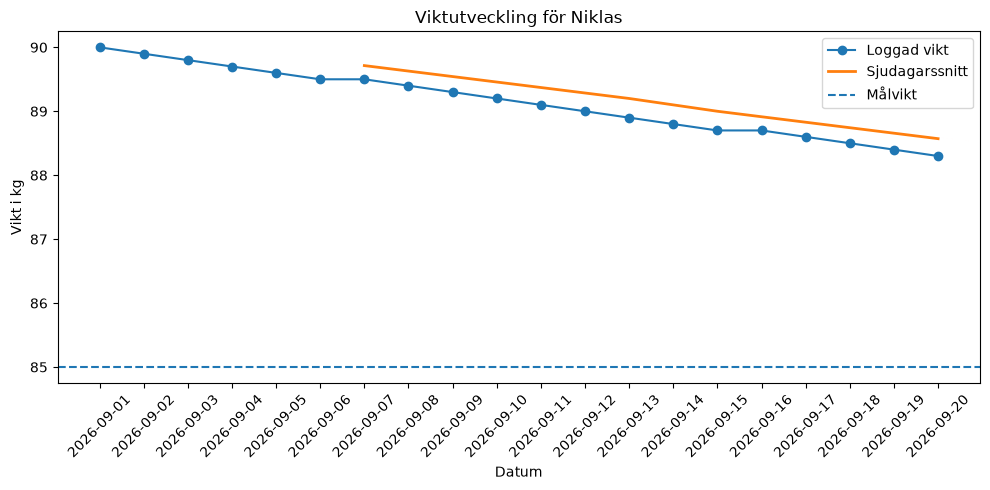

In [128]:
plot_test = CutProfile("Niklas", 183, 39, "man", 1.55, 90.0, "2026-09-01",
                       goal_weight=85.0, target_rate_percent=0.7)
add_days_of_logs(plot_test, "2026-09-01", 20, 90.0, -0.09, 2200, 150, 8000,
                 [True, False, True])

plot_weight(plot_test)

In [129]:
too_few = CutProfile("Test", 183, 39, "man", 1.55, 90.0, "2026-09-01",
                     goal_weight=85.0, target_rate_percent=0.7)
too_few.add_log(DailyLog("2026-09-15", 90.0, 2200, 150, 8000, True))
plot_weight(too_few)

Loggen för 2026-09-15 lades till.
Det behövs minst två loggar för att rita ett diagram.


## Resultat, exempeldata för README

Cellerna nedan bygger en 20 dagars datamängd som används i README:s resultatavsnitt. Siffrorna är konstruerade för att spegla min egen verkliga rutin, kalorier, proteinintervall, stegintervall, träningsfrekvens och kroppsmått, men de är simulerade, inte en logg förd dag för dag.

Midjemåttet är med en gång i veckan, dag 1, 8 och 15, resten `None`, eftersom produktvision.md säger att midjan typiskt mäts en gång i veckan, inte dagligen.

In [130]:
demo_user = CutProfile("Testperson", 189, 39, "man", 1.55, 101.5, "2026-09-17",
                       goal_weight=98.0, target_rate_percent=0.6,
                       protein_goal_per_kg=2.1, step_goal=10000, training_goal_days=5)

demo_data = [
    ("2026-09-17", 101.3, 204, 10243, True, 90.0),
    ("2026-09-18", 101.0, 192, 10916, True, None),
    ("2026-09-19", 101.0, 225, 8257, False, None),
    ("2026-09-20", 100.6, 198, 10311, True, None),
    ("2026-09-21", 100.5, 208, 8244, True, None),
    ("2026-09-22", 100.3, 216, 10535, False, None),
    ("2026-09-23", 100.0, 199, 8843, True, None),
    ("2026-09-24", 99.9, 224, 10033, True, 89.0),
    ("2026-09-25", 99.5, 197, 10786, False, None),
    ("2026-09-26", 99.3, 226, 10177, True, None),
    ("2026-09-27", 98.9, 209, 9751, True, None),
    ("2026-09-28", 98.6, 225, 11183, False, None),
    ("2026-09-29", 98.4, 201, 9286, True, None),
    ("2026-09-30", 98.6, 196, 9907, True, None),
    ("2026-10-01", 98.2, 227, 10398, True, 88.2),
    ("2026-10-02", 97.9, 226, 11782, True, None),
    ("2026-10-03", 97.9, 230, 9856, False, None),
    ("2026-10-04", 98.2, 202, 9481, True, None),
    ("2026-10-05", 98.1, 213, 9227, False, None),
    ("2026-10-06", 98.0, 196, 9017, True, None),
]

for date, weight, protein, steps, trained, waist in demo_data:
    demo_user.add_log(DailyLog(date, weight, 2300, protein, steps, trained, waist))

Loggen för 2026-09-17 lades till.
Loggen för 2026-09-18 lades till.
Loggen för 2026-09-19 lades till.
Loggen för 2026-09-20 lades till.
Loggen för 2026-09-21 lades till.
Loggen för 2026-09-22 lades till.
Loggen för 2026-09-23 lades till.
Loggen för 2026-09-24 lades till.
Loggen för 2026-09-25 lades till.
Loggen för 2026-09-26 lades till.
Loggen för 2026-09-27 lades till.
Loggen för 2026-09-28 lades till.
Loggen för 2026-09-29 lades till.
Loggen för 2026-09-30 lades till.
Loggen för 2026-10-01 lades till.
Loggen för 2026-10-02 lades till.
Loggen för 2026-10-03 lades till.
Loggen för 2026-10-04 lades till.
Loggen för 2026-10-05 lades till.
Loggen för 2026-10-06 lades till.


### Utskrifter vid olika tidpunkter

Samma profil, kontrollerad efter 14, 18 och 20 dagar, för att visa att `check_goals` ger olika besked i takt med att datan växer.

In [131]:
for cutoff in [14, 18, 20]:
    demo_partial = CutProfile("Testperson", 189, 39, "man", 1.55, 101.5, "2026-09-17",
                              goal_weight=98.0, target_rate_percent=0.6,
                              protein_goal_per_kg=2.1, step_goal=10000, training_goal_days=5)
    for date, weight, protein, steps, trained, waist in demo_data[:cutoff]:
        demo_partial.add_log(DailyLog(date, weight, 2300, protein, steps, trained, waist))

    print(f"=== Efter {cutoff} dagar ===")
    demo_partial.check_goals()
    print()

Loggen för 2026-09-17 lades till.
Loggen för 2026-09-18 lades till.
Loggen för 2026-09-19 lades till.
Loggen för 2026-09-20 lades till.
Loggen för 2026-09-21 lades till.
Loggen för 2026-09-22 lades till.
Loggen för 2026-09-23 lades till.
Loggen för 2026-09-24 lades till.
Loggen för 2026-09-25 lades till.
Loggen för 2026-09-26 lades till.
Loggen för 2026-09-27 lades till.
Loggen för 2026-09-28 lades till.
Loggen för 2026-09-29 lades till.
Loggen för 2026-09-30 lades till.
=== Efter 14 dagar ===
Vikten: minskar med 1.31 procent per vecka, över säkerhetsgränsen 1,0 procent. Risk för muskelförlust.
Protein: snitt 211 g mot mål 206 g. Målet nås.
Träning: 5 av 5 planerade dagar den senaste veckan. Målet nås.
Steg: snitt 10160 mot mål 10000. Målet nås.

Fokusera på: vikt.

Loggen för 2026-09-17 lades till.
Loggen för 2026-09-18 lades till.
Loggen för 2026-09-19 lades till.
Loggen för 2026-09-20 lades till.
Loggen för 2026-09-21 lades till.
Loggen för 2026-09-22 lades till.
Loggen för 2026-09-

### Kaloriförslag och diagram för hela perioden

In [132]:
demo_user.suggest_calorie_goal()
print(f"Kaloriförslag: {demo_user.calorie_goal} kcal per dag.")
print(f"Faktiskt intag i datan: 2300 kcal per dag.")

Kaloriförslag: 2409 kcal per dag.
Faktiskt intag i datan: 2300 kcal per dag.


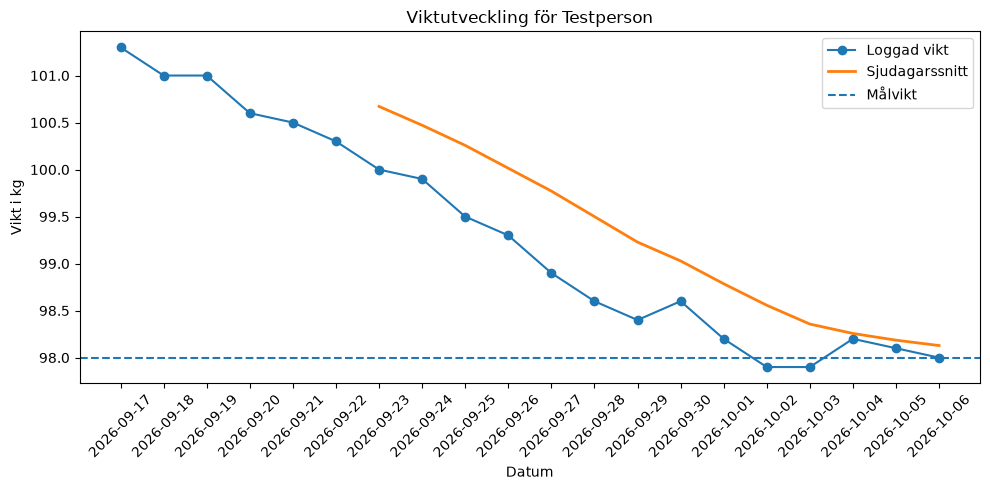

In [133]:
plot_weight(demo_user)

## Menyn

Det sista steget binder ihop allt. Tre funktioner: `show_welcome` visar välkomsttext och riktlinjer, `create_profile` frågar efter uppgifterna som behövs för en ny profil, och `run_menu` är huvudloopen.

All inmatning och utskrift ligger här, separat från klasserna och beräkningarna. Skulle programmet senare få ett grafiskt gränssnitt behöver bara de här funktionerna bytas ut, inte `CutProfile` eller `DailyLog`.

### show_welcome

Riktlinjerna är formulerade som principer utan exakta siffror. Skälet: en siffra här skulle kunna krocka med användarens egna inställningar. Säger texten 10 000 steg och användaren väljer aktivitetsnivå stillasittande, motsäger programmet sig självt. Principer, som att hålla aktiviteten uppe, fungerar oavsett vilken nivå personen valt.

Ansvarsfriskrivningen ligger sist, enligt produktvision.md. Den ska synas både här och vid kaloriberäkningen.

Strukturen skapas med tomrader och indrag, inte med ramar eller centrering. Det håller koden enkel och fungerar oavsett hur brett terminalfönstret är.

In [134]:
def show_welcome():
    """Visar välkomsttext, riktlinjer och ansvarsfriskrivning."""
    print()
    print("CutTrack")
    print()
    print("Ett verktyg för dig som deffar och vill behålla muskelmassan på vägen.")
    print()
    print("Vad som krävs för att lyckas:")
    print()
    print("  Styrketräna regelbundet. Frekvensen är det som håller muskelmassan uppe,")
    print("  inte hur långa passen är.")
    print()
    print("  Ät tillräckligt med protein. Målet räknas på din målvikt och ligger fast")
    print("  genom hela deffen.")
    print()
    print("  Håll din dagliga aktivitet uppe. Steg utanför träningen påverkar")
    print("  förbrukningen mer än de flesta tror.")
    print()
    print("  Håll ett måttligt kaloriunderskott. För stort underskott kostar")
    print("  muskelmassa utan att gå snabbare i längden.")
    print()
    print("  Logga varje dag. Programmet väntar 14 dagar innan det bedömer takten,")
    print("  eftersom dagliga vägningar svänger mer än en hel veckas fettförlust.")
    print()
    print("Observera: CutTrack ger allmänna riktvärden baserade på etablerade")
    print("rekommendationer. Det är inte medicinsk rådgivning. Rådgör med läkare")
    print("eller dietist vid sjukdom, graviditet eller medicinering.")
    print()

### ask_number och create_profile

`ask_number` löser ett problem som återkommer överallt: `input()` ger alltid text, och `float("abc")` kastar `ValueError`. I stället för att skriva samma try/except sju gånger ligger den i en egen funktion med en `while True`-loop som frågar om tills svaret går att tolka.

`create_profile` frågar efter allt som behövs. Tre olika sorters kontroller används:

- **Tal**, via `ask_number`
- **Kön**, en `while`-loop som kör tills svaret är man eller kvinna
- **Aktivitetsnivå**, en dictionary som kopplar siffran 1 till 5 till rätt faktor. Användaren slipper veta att 1,55 betyder måttligt aktiv

Vikterna och takten frågas i en egen `while True`-loop, eftersom de valideras tillsammans i `CutProfile.__init__`. Är målvikten högre än startvikten kastas `ValueError`, och alla tre frågorna ställs om. De går inte att kontrollera var för sig, eftersom felet uppstår först i kombinationen.

`datetime.now().strftime("%Y-%m-%d")` sätter dagens datum som startdatum, i samma format som resten av programmet använder.

In [135]:
def ask_number(question, is_integer=False):
    """Frågar tills användaren skriver ett giltigt tal."""
    while True:
        answer = input(question)
        try:
            if is_integer:
                return int(answer)
            return float(answer)
        except ValueError:
            print("Skriv ett tal, till exempel 82.5.")

In [136]:
def create_profile(name):
    """Frågar efter uppgifterna som behövs och skapar en ny CutProfile."""
    print()
    print("Ny profil. Svara på några frågor så räknar programmet ut ditt kaloriförslag.")
    print()

    height_cm = ask_number("Längd i cm: ", True)
    age = ask_number("Ålder: ", True)

    sex = ""
    while sex != "man" and sex != "kvinna":
        sex = input("Kön (man/kvinna): ").lower()
        if sex != "man" and sex != "kvinna":
            print("Skriv man eller kvinna.")

    print()
    print("Aktivitetsnivå:")
    print("  1  Stillasittande")
    print("  2  Lätt aktiv")
    print("  3  Måttligt aktiv")
    print("  4  Mycket aktiv")
    print("  5  Extremt aktiv")

    # Dictionary så användaren slipper veta vad faktorerna betyder
    activity_levels = {1: 1.2, 2: 1.375, 3: 1.55, 4: 1.725, 5: 1.9}

    activity_choice = 0
    while activity_choice not in activity_levels:
        activity_choice = ask_number("Välj 1 till 5: ", True)
        if activity_choice not in activity_levels:
            print("Välj ett tal mellan 1 och 5.")

    activity_level = activity_levels[activity_choice]

    print()
    # Vikterna och takten valideras tillsammans i CutProfile, så alla tre frågas om vid fel
    while True:
        start_weight = ask_number("Startvikt i kg: ")
        goal_weight = ask_number("Målvikt i kg: ")
        target_rate = ask_number("Önskad takt i procent per vecka (0.5 till 1.0): ")

        try:
            created_date = datetime.now().strftime("%Y-%m-%d")
            profile = CutProfile(name, height_cm, age, sex, activity_level,
                                 start_weight, created_date, goal_weight, target_rate)
            return profile
        except ValueError as error:
            print(f"Det gick inte: {error}")
            print("Försök igen.")

### run_menu

Huvudloopen. Först visas välkomsttexten, sedan frågas efter namnet. `load_profile` returnerar `None` om ingen sparad fil finns, och då skapas en ny profil i stället.

`while running:` med en boolean i stället för `while True:` och `break`. Båda fungerar, men den här varianten gör det tydligare var loopen avslutas, och den använder bool som datatyp på ett naturligt sätt.

Menyvalen jämförs som text, `choice == "1"`, inte som tal. Skälet är att `input()` ger text, och `int("abc")` hade kastat ett fel som behövt fångas. Med textjämförelse fångas ogiltiga val av det avslutande `else`.

Vid avslut sparas profilen som JSON och loggarna exporteras som CSV, enligt teknisk_plan.md. Det gör att datafilen som ska lämnas in skapas automatiskt varje gång programmet avslutas normalt.

In [137]:
def run_menu():
    """Programmets huvudloop."""
    show_welcome()

    name = input("Vad heter du? ")
    profile = load_profile(name)

    if profile is None:
        profile = create_profile(name)
        print()
        print(f"Profil skapad för {profile.name}.")
        print()
        profile.suggest_calorie_goal()
        print(f"Ditt kaloriförslag: {profile.calorie_goal} kcal per dag.")
        print(f"Ditt proteinmål: {round(profile.protein_goal())} gram per dag.")

    running = True
    while running:
        print()
        print("Meny")
        print("  1  Logga dagens data")
        print("  2  Visa analys")
        print("  3  Visa viktdiagram")
        print("  4  Visa kaloriförslag")
        print("  5  Läs in loggar från CSV")
        print("  6  Spara och avsluta")
        print()

        choice = input("Välj: ")

        if choice == "1":
            log_today(profile)
        elif choice == "2":
            print()
            profile.check_goals()
        elif choice == "3":
            plot_weight(profile)
        elif choice == "4":
            print()
            profile.suggest_calorie_goal()
            print(f"Kaloriförslag: {profile.calorie_goal} kcal per dag.")
            print(f"Proteinmål: {round(profile.protein_goal())} gram per dag.")
        elif choice == "5":
            filename = input("Filnamn (tomt för cuttrack_loggar.csv): ")
            if filename == "":
                filename = "cuttrack_loggar.csv"
            import_logs_csv(profile, filename)
        elif choice == "6":
            save_profile(profile)
            export_logs_csv(profile)
            print("Hej då.")
            running = False
        else:
            print("Välj ett tal mellan 1 och 6.")

## Kör programmet

Cellen nedan startar CutTrack. Den väntar på inmatning, så den stannar när du kör Run All, tills du svarar eller avbryter cellen.

Testa gärna både en ny profil och att starta om och ladda samma profil igen, så ser du att sparningen fungerar. Testa också att skriva fel med flit, bokstäver där tal förväntas, en målvikt högre än startvikten, och ett menyval som inte finns.

In [138]:
run_menu()


CutTrack

Ett verktyg för dig som deffar och vill behålla muskelmassan på vägen.

Vad som krävs för att lyckas:

  Styrketräna regelbundet. Frekvensen är det som håller muskelmassan uppe,
  inte hur långa passen är.

  Ät tillräckligt med protein. Målet räknas på din målvikt och ligger fast
  genom hela deffen.

  Håll din dagliga aktivitet uppe. Steg utanför träningen påverkar
  förbrukningen mer än de flesta tror.

  Håll ett måttligt kaloriunderskott. För stort underskott kostar
  muskelmassa utan att gå snabbare i längden.

  Logga varje dag. Programmet väntar 14 dagar innan det bedömer takten,
  eftersom dagliga vägningar svänger mer än en hel veckas fettförlust.

Observera: CutTrack ger allmänna riktvärden baserade på etablerade
rekommendationer. Det är inte medicinsk rådgivning. Rådgör med läkare
eller dietist vid sjukdom, graviditet eller medicinering.

Ingen sparad profil hittades för loggen för 2026-12-31.

Ny profil. Svara på några frågor så räknar programmet ut ditt kalori